## Regression Cases

# Simple Linear Regression 1

Purpose is to build a simple linear regresion model using the number of car insurance claims in predicting the amount paid out from the number of car insurance claims.

In [7]:
import pandas as pd
import matplotlib.pyplot as plot
import statsmodels.api as stats
import numpy as np

Loading the data

In [8]:
insurance_df =pd.read_csv('auto_insurance_sweden.csv')

Assessing the data

In [9]:
insurance_df.shape

(63, 2)

In [10]:
insurance_df.head()

,claims,payment
0,108,392.5
1,19,46.2
2,13,15.7
3,124,422.2
4,40,119.4


## Visualisation of the data

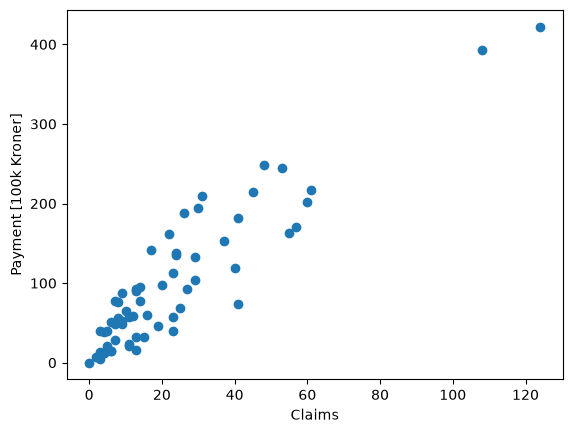

In [11]:
plot.scatter(insurance_df.claims, insurance_df.payment)
plot.xlabel('Claims')
plot.ylabel('Payment [100k Kroner]')
plot.show()

## Fitting the linear regression model

In [12]:
Y_insurance = insurance_df.payment
X_insurance = stats.add_constant(insurance_df['claims'])

In [13]:
model_insurance = stats.OLS(Y_insurance, X_insurance)
results_insurance = model_insurance.fit()

In [57]:
print(results_insurance.summary())

                            OLS Regression Results                            
Dep. Variable:                payment   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     305.0
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           2.05e-25
Time:                        19:09:30   Log-Likelihood:                -314.04
No. Observations:                  63   AIC:                             632.1
Df Residuals:                      61   BIC:                             636.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.9945      6.368      3.140      0.0

## Viewing line parameters

In [14]:
intercept_insurance = results_insurance.params.iloc[0]
claims_coeff = results_insurance.params.iloc[1]
ssr_insurance = results_insurance.ssr

print('The intercept value is {:.3f}'.format(intercept_insurance))
print('The coefficient (slope) for the claims independent variable is {:.3f}'.format(claims_coeff))
print('The sum of square residuals is {:.1f}'.format(ssr_insurance))

The intercept value is 19.994
The coefficient (slope) for the claims independent variable is 3.414
The sum of square residuals is 78796.7


## Plotting results

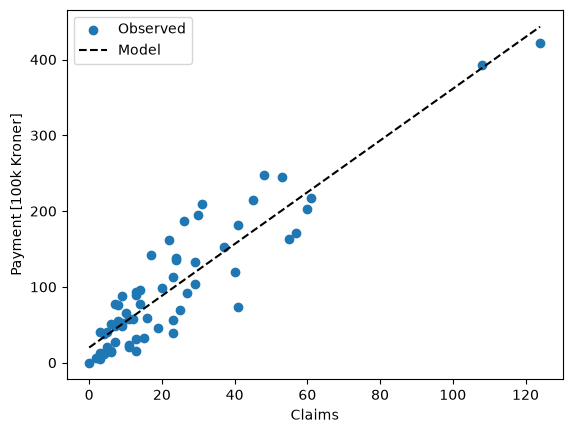

In [15]:
# training observations
plot.scatter(insurance_df.claims, insurance_df.payment, label='Observed')

# line of best fit
x_synthetic = np.linspace(0,insurance_df.claims.max(), 50)
y_pred_insurance = claims_coeff*x_synthetic + intercept_insurance
plot.plot(x_synthetic, y_pred_insurance, color='k', ls='--', label='Model')

# plot combined chart
plot.xlabel('Claims')
plot.ylabel('Payment [100k Kroner]')
plot.legend()
plot.show()

# Simple Linear Regression 2

This exercise will use a larger dataset that has both more datapoints and more independent variables. The dataset contains data on various car models and here I want to predict the car price from its features. We will only use one of these variables for the moment. I will also split the data into a training set and test set so we can apply the model to unseen data.

Import required packages and dataset into the workbook.

In [16]:
import pandas as pd
import matplotlib.pyplot as plot
import statsmodels.api as stats
import numpy as np

In [17]:
carprice_df = pd.read_csv('CarPrice_Assignment.csv')

Assessing the data

In [18]:
carprice_df.shape

(205, 26)

In [19]:
carprice_df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


## Test/Train Split

I will train the model on 70% of the data and test its results on the remaining 30%. The df.sample() method takes a random sample of the dataframe with size specified by frac argument. I can then get the test set as the remaining rows not in this random sample.

In [20]:
train_df = carprice_df.sample(frac=0.7, random_state=99)
test_df = carprice_df.drop(train_df.index)

In [21]:
train_df.shape

(144, 26)

In [22]:
test_df.shape

(61, 26)

## Visualizing the data

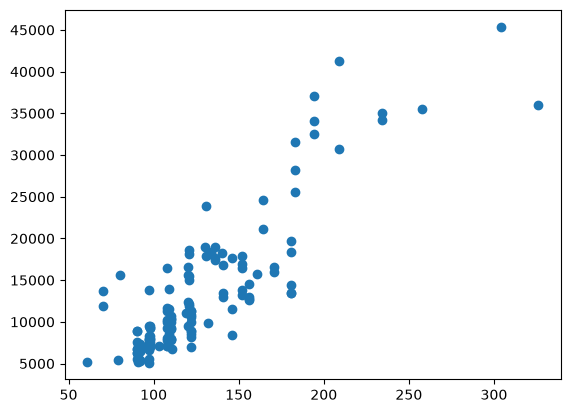

In [23]:
plot.scatter(train_df.enginesize, train_df.price)

## Fitting linear regression model

In [24]:
y_train = train_df.price
x_train = stats.add_constant(train_df.enginesize)

In [25]:
model_carprice = stats.OLS(y_train,x_train)
results_carprice = model_carprice.fit()

In [26]:
print(results_carprice.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.751
Method:                 Least Squares   F-statistic:                     431.6
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           6.87e-45
Time:                        19:47:53   Log-Likelihood:                -1399.1
No. Observations:                 144   AIC:                             2802.
Df Residuals:                     142   BIC:                             2808.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7969.4448   1068.536     -7.458      0.0

In [27]:
intercept_carprice = results_carprice.params.iloc[0]
engsize_coeff = results_carprice.params.iloc[1]
ssr_carprice = results_carprice.ssr

print('The intercept value is {:.3f}'.format(intercept_carprice))
print('The coefficient (slope) for the years of experience independent variable is {:.3f}'.format(engsize_coeff))
print('The sum of square residuals is {:.1f}'.format(ssr_carprice))

The intercept value is -7969.445
The coefficient (slope) for the years of experience independent variable is 167.600
The sum of square residuals is 2319259109.3


## Plotting results

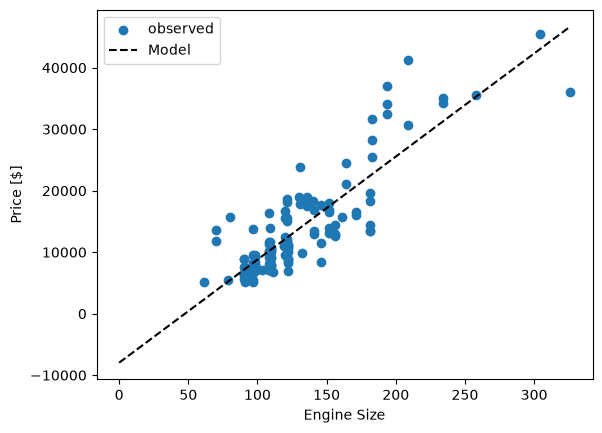

In [28]:
# observations
plot.scatter(train_df.enginesize, train_df.price, label='observed')

# line of best fit
x_synthetic = np.linspace(0,train_df.enginesize.max(),50)
y_pred_carprice = x_synthetic * engsize_coeff + intercept_carprice
plot.plot(x_synthetic,y_pred_carprice,color='k', ls='--', label='Model')

#plot results
plot.xlabel('Engine Size')
plot.ylabel('Price [$]')
plot.legend()
plot.show()

## Applying model to test data

I can apply the model to the test data and use it to make predictions for the test data that wasn't used to bulild the model. I can compare these predictions with the actual observed values. I can use the results.predict() method to predict for the test data. I first split the target and independent variable and add a constant column to the independent varialbe.

In [29]:
y_test = test_df.price
x_test = stats.add_constant(test_df.enginesize)

In [30]:
test_pred = results_carprice.predict(x_test)

I can plot the predictions against the observed values to see how good the predictions were. The closer to the diagonal line where predictions equal observed the better.

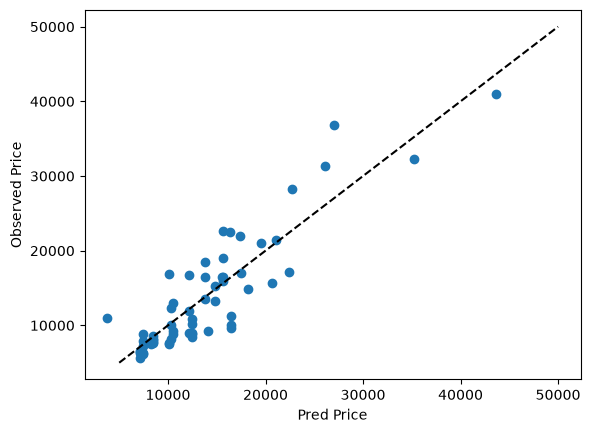

In [31]:
plot.scatter(test_pred,y_test)
plot.plot([5000,50000],[5000,50000], c='k', ls='--')
plot.xlabel('Pred Price')
plot.ylabel('Observed Price')
plot.show()

# Multiple Linear Regression 

## Package and Data Loading

In [32]:
import pandas as pd
import matplotlib.pyplot as plot
import statsmodels.api as stats
import numpy as np

In [33]:
carprice_df = pd.read_csv('CarPrice_Assignment.csv')

Assessing the data

In [34]:
carprice_df.shape

(205, 26)

In [35]:
carprice_df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [36]:
carprice_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

In [37]:
carprice_df.select_dtypes(include='str').nunique()

CarName           147
fueltype            2
aspiration          2
doornumber          2
carbody             5
drivewheel          3
enginelocation      2
enginetype          7
cylindernumber      7
fuelsystem          8
dtype: int64

The data contains a mixture of numeric types and categorical types. I will remove the car_ID field from the data as this is only an identifier. For the purposes of this exercise I will also remove CarName from the data as it contains a large number of unique values.

In [38]:
carprice_df = carprice_df.drop(columns=['car_ID', 'CarName'])

## Basic Multiple Regression

In [39]:
Y_basic = carprice_df.price
X_basic = stats.add_constant(carprice_df[['enginesize', 'curbweight', 'peakrpm', 'citympg']])

In [40]:
model_basic = stats.OLS(Y_basic, X_basic)
results_basic = model_basic.fit()

In [41]:
print(results_basic.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     225.0
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           7.62e-73
Time:                        19:48:20   Log-Likelihood:                -1957.7
No. Observations:                 205   AIC:                             3925.
Df Residuals:                     200   BIC:                             3942.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.022e+04   5937.020     -5.090      0.0

# Full Multiple Regression Model

I can look at the correlations between different numerical variables in a handy way using a correlation matrix, this allows me to see the correlation between all pairs of variables at once. I can then remove some of the independent variables that are highly correlated and would cause problems with the algorithm due to multicollinearity. I can create this correlation matrix using the df.corr() method. I can add a red/blue heatmap to better see where the extreme correlations are.

In [42]:
carprice_df.select_dtypes(exclude='object').corr().style.background_gradient(cmap='coolwarm')

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
symboling,1.000000,-0.531954,-0.357612,-0.232919,-0.541038,-0.227691,-0.105790,-0.130051,-0.008735,-0.178515,0.070873,0.273606,-0.035823,0.034606,-0.079978
wheelbase,-0.531954,1.000000,0.874587,0.795144,0.589435,0.776386,0.569329,0.488750,0.160959,0.249786,0.353294,-0.360469,-0.470414,-0.544082,0.577816
carlength,-0.357612,0.874587,1.000000,0.841118,0.491029,0.877728,0.683360,0.606454,0.129533,0.158414,0.552623,-0.287242,-0.670909,-0.704662,0.682920
carwidth,-0.232919,0.795144,0.841118,1.000000,0.279210,0.867032,0.735433,0.559150,0.182942,0.181129,0.640732,-0.220012,-0.642704,-0.677218,0.759325
carheight,-0.541038,0.589435,0.491029,0.279210,1.000000,0.295572,0.067149,0.171071,-0.055307,0.261214,-0.108802,-0.320411,-0.048640,-0.107358,0.119336
curbweight,-0.227691,0.776386,0.877728,0.867032,0.295572,1.000000,0.850594,0.648480,0.168790,0.151362,0.750739,-0.266243,-0.757414,-0.797465,0.835305
enginesize,-0.105790,0.569329,0.683360,0.735433,0.067149,0.850594,1.000000,0.583774,0.203129,0.028971,0.809769,-0.244660,-0.653658,-0.677470,0.874145
boreratio,-0.130051,0.488750,0.606454,0.559150,0.171071,0.648480,0.583774,1.000000,-0.055909,0.005197,0.573677,-0.254976,-0.584532,-0.587012,0.553173
stroke,-0.008735,0.160959,0.129533,0.182942,-0.055307,0.168790,0.203129,-0.055909,1.000000,0.186110,0.080940,-0.067964,-0.042145,-0.043931,0.079443
compressionratio,-0.178515,0.249786,0.158414,0.181129,0.261214,0.151362,0.028971,0.005197,0.186110,1.000000,-0.204326,-0.435741,0.324701,0.265201,0.067984


In [43]:
carprice_df = carprice_df.drop(columns = ['carlength', 'carwidth', 'highwaympg'])

In [44]:
dummy = pd.get_dummies(carprice_df.select_dtypes(include='str'), drop_first=True)

In [45]:
carprice_df = pd.concat([carprice_df.select_dtypes(exclude='str'), dummy], axis=1)

In [46]:
carprice_df.corr().style.background_gradient(cmap='coolwarm')

,symboling,wheelbase,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,price,fueltype_gas,aspiration_turbo,doornumber_two,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,drivewheel_fwd,drivewheel_rwd,enginelocation_rear,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,cylindernumber_five,cylindernumber_four,cylindernumber_six,cylindernumber_three,cylindernumber_twelve,cylindernumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
symboling,1.000000,-0.531954,-0.541038,-0.227691,-0.105790,-0.130051,-0.008735,-0.178515,0.070873,0.273606,-0.035823,-0.079978,0.194311,-0.059866,0.664073,0.168845,0.435648,-0.378341,-0.298243,0.102839,-0.076381,0.212471,0.009347,-0.133979,-0.082855,0.037513,-0.013597,0.245950,-0.090188,-0.034161,-0.000238,0.065707,-0.047012,0.245950,-0.034069,0.212471,-0.194311,0.122067,0.012532,0.181939,0.065707
wheelbase,-0.531954,1.000000,0.589435,0.776386,0.569329,0.488750,0.160959,0.249786,0.353294,-0.360469,-0.470414,0.577816,-0.308346,0.257611,-0.447357,-0.008608,-0.386094,0.291086,0.210899,-0.460355,0.498830,-0.187790,-0.004156,0.399603,-0.204037,-0.183195,0.166152,-0.081174,0.261182,-0.309492,0.145842,-0.120709,0.037803,-0.081174,-0.396505,-0.070124,0.308346,-0.033294,0.348891,-0.117359,-0.032129
carheight,-0.541038,0.589435,1.000000,0.295572,0.067149,0.171071,-0.055307,0.261214,-0.108802,-0.320411,-0.048640,0.119336,-0.284631,0.087311,-0.552208,-0.072328,-0.477476,0.235863,0.459148,-0.100273,0.039814,-0.106234,-0.092628,0.319687,0.036260,-0.046670,-0.065063,-0.238720,0.152982,0.059696,-0.049777,-0.015076,-0.170181,-0.238720,-0.079418,-0.206225,0.284631,-0.101245,0.108685,-0.278615,-0.066778
curbweight,-0.227691,0.776386,0.295572,1.000000,0.850594,0.648480,0.168790,0.151362,0.750739,-0.266243,-0.757414,0.835305,-0.217275,0.324902,-0.197379,0.098956,-0.287501,0.099425,0.164075,-0.666039,0.669987,0.050468,0.109243,0.250124,-0.413293,-0.080295,0.400878,-0.039196,0.264554,-0.576463,0.405490,-0.143903,0.187964,-0.039196,-0.577159,-0.040801,0.217275,0.034431,0.520220,-0.002434,0.024052
enginesize,-0.105790,0.569329,0.067149,0.850594,1.000000,0.583774,0.203129,0.028971,0.809769,-0.244660,-0.653658,0.874145,-0.069594,0.108217,-0.020742,0.239363,-0.216805,0.088459,-0.027518,-0.518391,0.565509,0.196826,0.128248,0.016063,-0.363334,-0.016508,0.562403,-0.184762,0.144878,-0.631431,0.511783,-0.111081,0.335555,-0.184762,-0.442562,-0.166946,0.069594,0.049033,0.483520,0.004490,-0.013327
boreratio,-0.130051,0.488750,0.171071,0.648480,0.583774,1.000000,-0.055909,0.005197,0.573677,-0.254976,-0.584532,0.553173,-0.054451,0.212614,-0.119258,0.208089,-0.227032,0.030517,0.105719,-0.583087,0.574105,0.185042,0.158136,0.181729,-0.410383,0.326798,0.119509,0.000127,-0.007797,-0.164076,0.128365,-0.108774,0.054482,0.000127,-0.353342,0.000110,0.054451,0.070030,0.419335,-0.004213,0.025977
stroke,-0.008735,0.160959,-0.055307,0.168790,0.203129,-0.055909,1.000000,0.186110,0.080940,-0.067964,-0.042145,0.079443,-0.241829,0.222982,0.011082,0.043215,0.052316,0.035630,-0.095084,0.124397,-0.022325,-0.138455,-0.032545,-0.084688,0.366084,-0.522808,-0.044813,-0.000187,0.176485,-0.111046,0.068388,-0.050450,-0.110878,-0.000187,-0.234866,-0.000162,0.241829,0.144263,-0.110280,0.251259,-0.005688
compressionratio,-0.178515,0.249786,0.261214,0.151362,0.028971,0.005197,0.186110,1.000000,-0.204326,-0.435741,0.324701,0.067984,-0.984356,0.295541,-0.177888,0.029623,-0.202650,0.188286,0.016315,-0.062683,0.105185,-0.019762,-0.002519,0.219153,0.027545,-0.084328,-0.086649,-0.026436,0.173360,-0.012522,-0.065559,-0.011354,0.023986,-0.026436,-0.183384,-0.022838,0.984356,-0.055528,-0.311035,-0.153726,-0.016654
horsepower,0.070873,0.353294,-0.108802,0.750739,0.809769,0.573677,0.080940,-0.204326,1.000000,0.131073,-0.801456,0.808139,0.163926,0.241685,0.126947,0.194801,-0.053770,-0.024097,-0.063081,-0.544438,0.57

In [47]:
carprice_df = carprice_df.drop(columns=['compressionratio', 'drivewheel_fwd', 'enginetype_rotor', 'fuelsystem_4bbl', 'fuelsystem_idi'])

In [48]:
carprice_df.shape

(205, 36)

## Test/Train Split

In [49]:
train_df = carprice_df.sample(frac = 0.7, random_state = 99) #random state is a seed value
test_df = carprice_df.drop(train_df.index)

In [52]:
train_df.shape

(144, 36)

In [53]:
test_df.shape

(61, 36)

## Fitting the Linear Regression Model

I use the statsmodels to fit the linear regression model. I do this in the same way as other models except now our X_train contains all of our independent variables.

In [54]:
Y_train = train_df.price

In [55]:
X_train = stats.add_constant(train_df.drop(columns=['price'])).astype(float)

In [56]:
model_carprice = stats.OLS(Y_train, X_train)
results_carprice = model_carprice.fit()

In [57]:
print(results_carprice.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                     48.60
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           1.43e-51
Time:                        19:48:45   Log-Likelihood:                -1299.3
No. Observations:                 144   AIC:                             2669.
Df Residuals:                     109   BIC:                             2773.
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  -1.11e+

In [58]:
print('The sum of square residuals is {:.1f}'.format(results_carprice.ssr))

The sum of square residuals is 579728377.8


I will also use the test set to compare to the predictions with the observed values.

In [59]:
Y_test = test_df.price
test_df = stats.add_constant(test_df)
X_test = test_df[X_train.columns]

In [60]:
test_predictions = results_carprice.predict(X_test)

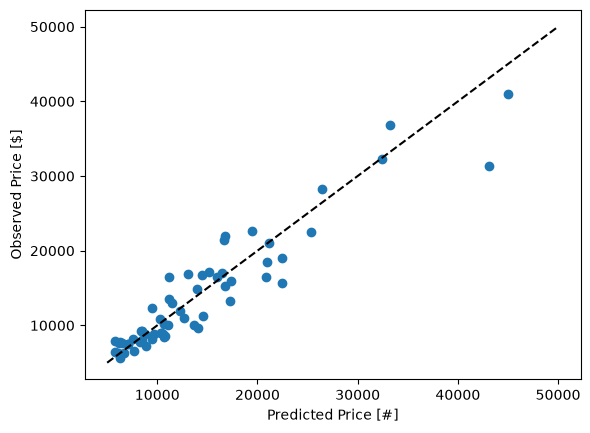

In [61]:
plot.scatter(test_predictions, Y_test)
plot.plot([5000, 50000], [5000, 50000], c='k', ls='--')
plot.xlabel('Predicted Price [#]')
plot.ylabel('Observed Price [$]')
plot.show()

## Scikit-Learn

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Test/Train Split

In [63]:
Y = carprice_df.price
X = carprice_df.drop(columns=['price'])

In [64]:
sk_X_train, sk_X_test, sk_Y_train, sk_Y_test = train_test_split(X,Y, test_size=0.3, random_state=99)

In [65]:
regressor = LinearRegression()
regressor.fit(sk_X_train, sk_Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](35,)","[ 252.33, 74.13, 83.09,..., 8.8 ,-2196.94, 0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](35,)","['symboling','wheelbase','carheight',...,'fuelsystem_mpfi', 'fuelsystem_spdi','fuelsystem_spfi']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-5972
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,35
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(33)


In [66]:
sk_intercept_carprice = regressor.intercept_
sk_engsize_coeffs = regressor.coef_
sk_ssr_carprice = np.sum((sk_Y_train-regressor.predict(sk_X_train))**2)

In [67]:
pd.Series(sk_engsize_coeffs, index=sk_X_train.columns)

symboling                2.523350e+02
wheelbase                7.412976e+01
carheight                8.309020e+01
curbweight               4.839412e+00
enginesize               1.715172e+02
boreratio               -5.949063e+03
stroke                  -6.214262e+03
horsepower               2.217799e+01
peakrpm                  2.154338e+00
citympg                  4.212092e+01
fueltype_gas            -1.110769e+03
aspiration_turbo         2.083399e+03
doornumber_two          -6.671472e+01
carbody_hardtop         -2.879089e+03
carbody_hatchback       -2.613059e+03
carbody_sedan           -1.980960e+03
carbody_wagon           -3.223607e+03
drivewheel_rwd           2.109262e+02
enginelocation_rear      8.110262e+03
enginetype_dohcv         1.368412e+03
enginetype_l             4.717644e+02
enginetype_ohc           4.039236e+03
enginetype_ohcf          2.413523e+03
enginetype_ohcv         -2.760030e+03
cylindernumber_five     -1.192809e+03
cylindernumber_four     -1.295218e+03
cylindernumb

In [69]:
print('The intercept is {:.1f}'.format(sk_intercept_carprice))
print('The sum of square residuals is {:.1f}'.format(sk_ssr_carprice))

The intercept is -5972.4
The sum of square residuals is 496875718.4


# Interpreting Linear Regression

I will continue with the car price prediction example and explore the methods that can be used ot interpret and evaluate the results of the linear regression model. I will begin by reproducing the results.

In [70]:
import pandas as pd
import matplotlib.pyplot as plot
import statsmodels.api as stats
import numpy as np

In [89]:
carprice_df = pd.read_csv('CarPrice_Assignment.csv')

In [73]:
carprice_df = carprice_df.drop(columns = ['carlength', 'carwidth', 'highwaympg'])

In [74]:
dummy = pd.get_dummies(carprice_df.select_dtypes(include='str'), drop_first=True)

In [75]:
carprice_df = pd.concat([carprice_df.select_dtypes(exclude='str'), dummy], axis=1)

In [83]:
carprice_df = carprice_df.drop(columns=['compressionratio', 'drivewheel_fwd', 'enginetype_rotor', 'fuelsystem_4bbl', 'fuelsystem_idi'], errors='ignore')


In [84]:
train_df = carprice_df.sample(frac = 0.7, random_state = 101)
test_df = carprice_df.drop(train_df.index)

In [85]:
Y_train = train_df.price
X_train = stats.add_constant(train_df.drop(columns=['price'])).astype(float)

In [86]:
model_carprice = stats.OLS(Y_train, X_train)
results_carprice = model_carprice.fit()

In [87]:
Y_test = test_df.price
test_df = stats.add_constant(test_df)
X_test = test_df[X_train.columns]

In [88]:
test_predictions = results_carprice.predict(X_test)

## p-Values and Coefficients

p-Values

In [91]:
print(results_carprice.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     43.50
Date:                Sun, 21 Jun 2026   Prob (F-statistic):            0.00104
Time:                        20:03:13   Log-Likelihood:                -959.35
No. Observations:                 144   AIC:                             2199.
Df Residuals:                       4   BIC:                             2614.
Df Model:                         139                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

In [97]:
Y_train_new = train_df.price
X_train_new = stats.add_constant(train_df[['enginesize',
                                            'stroke',
                                            'peakrpm',
                                            'fueltype_gas',
                                            'carbody_hardtop',
                                            'carbody_hatchback',
                                            'enginelocation_rear',
                                            'enginetype_ohc',
                                            'cylindernumber_five',
                                            'cylindernumber_four',
                                            'cylindernumber_six']]).astype(float)

In [98]:
model_carprice_new = stats.OLS(Y_train_new, X_train_new)
results_carprice_new = model_carprice_new.fit()

In [99]:
print(results_carprice_new.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     90.22
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           8.02e-56
Time:                        20:08:11   Log-Likelihood:                -1332.3
No. Observations:                 144   AIC:                             2689.
Df Residuals:                     132   BIC:                             2724.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                5265.5852   3

In [101]:
Y_test_new = test_df.price
X_test_new = test_df[X_train_new.columns]

In [103]:
test_predictions_new = results_carprice_new.predict(X_test_new)

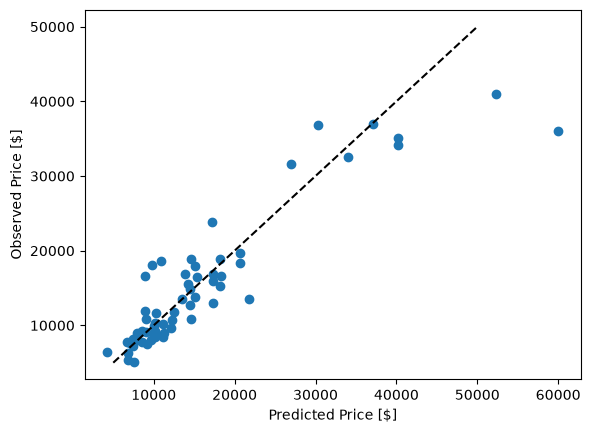

In [105]:
plot.scatter(test_predictions_new,Y_test_new)
plot.plot([5000,50000],[5000,50000], c='k', ls='--')
plot.xlabel('Predicted Price [$]')
plot.ylabel('Observed Price [$]')
plot.show()

## Coefficients

The coefficients tells how much the target variable changes for a one unit change in the corresponding independent variable when all the other independent variables are held fixed. I can get a measure of which independent variable contributes the most change to the target variable if we first scale all the independent variables to remove the units. This is standardization.

In [108]:
X_train_scale = ((X_train_new - X_train_new.mean())/X_train_new.std()).drop(columns=['const'])

In [109]:
X_train_scale.std()

enginesize             1.0
stroke                 1.0
peakrpm                1.0
fueltype_gas           1.0
carbody_hardtop        1.0
carbody_hatchback      1.0
enginelocation_rear    1.0
enginetype_ohc         1.0
cylindernumber_five    1.0
cylindernumber_four    1.0
cylindernumber_six     1.0
dtype: float64

In [111]:
X_train_scale.mean().round(2)

enginesize             0.0
stroke                 0.0
peakrpm                0.0
fueltype_gas          -0.0
carbody_hardtop        0.0
carbody_hatchback      0.0
enginelocation_rear    0.0
enginetype_ohc         0.0
cylindernumber_five   -0.0
cylindernumber_four    0.0
cylindernumber_six     0.0
dtype: float64

In [112]:
X_train_scale = stats.add_constant(X_train_scale)

In [113]:
model_carprice_scale = stats.OLS(Y_train_new, X_train_scale)
results_carprice_scale = model_carprice_scale.fit()

In [114]:
print(results_carprice_scale.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     90.22
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           8.02e-56
Time:                        20:14:34   Log-Likelihood:                -1332.3
No. Observations:                 144   AIC:                             2689.
Df Residuals:                     132   BIC:                             2724.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1.248e+04    

<Axes: >

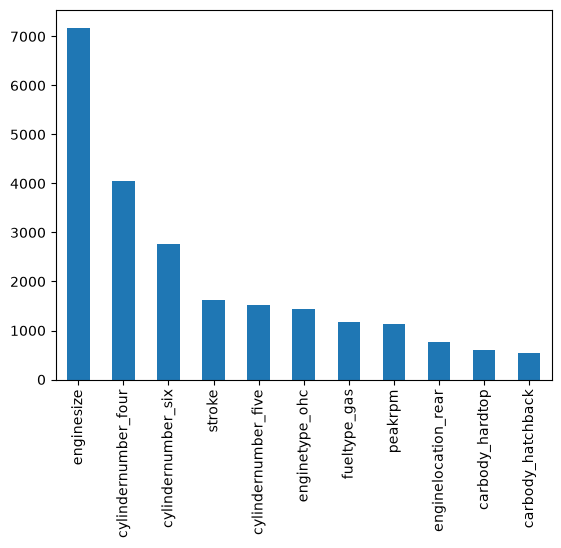

In [115]:
results_carprice_scale.params.drop(index=['const']).abs().sort_values(ascending=False).plot.bar()

## Residuals and Residual Plots

In [116]:
results_carprice_new.resid

120    -185.205528
185   -1485.475419
180   -3815.947168
119     872.815707
109    3492.490264
          ...     
86    -3061.198405
193    2037.957826
20    -1383.557493
155    1392.163478
10     2523.359750
Length: 144, dtype: float64

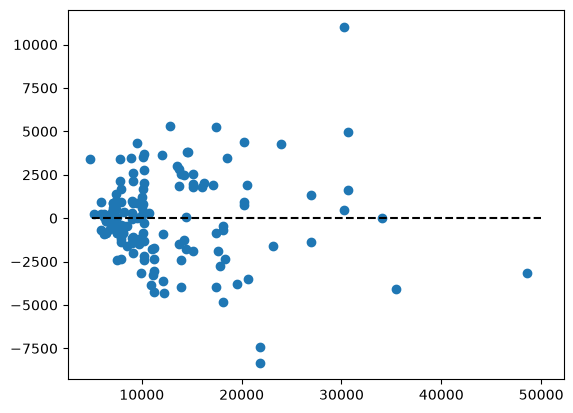

In [117]:
plot.scatter(results_carprice_new.fittedvalues, results_carprice_new.resid)
plot.plot([5000,50000], [0,0], c='k', ls='--')

# Evaluating Linear Regression Part 2

Statsmodels allows me to easily calculate the metrics that has been covered in this workbook.

In [118]:
train_mse = stats.tools.eval_measures.mse(Y_train_new, results_carprice_new.fittedvalues)
print('The training dataset mean square error is {}'.format(train_mse.round(1)))

The training dataset mean square error is 6361335.8


In [119]:
train_rmse = stats.tools.eval_measures.rmse(Y_train_new, results_carprice_new.fittedvalues)
print('The training dataset root mean square error is {}'.format(train_rmse.round(1)))

The training dataset root mean square error is 2522.2


In [120]:
train_mae = stats.tools.eval_measures.meanabs(Y_train_new, results_carprice_new.fittedvalues)
print('The training dataset mean absolute error is {}'.format(train_mae.round(1)))

The training dataset mean absolute error is 1851.4


In [121]:
train_r2 = results_carprice_new.rsquared
print('The training dataset coefficient of determination is {}'.format(train_r2.round(3)))

The training dataset coefficient of determination is 0.883


In [122]:
train_r2_adj = results_carprice_new.rsquared_adj
print('The training dataset adjusted coefficient of determination is {}'.format(train_r2_adj.round(3)))

The training dataset adjusted coefficient of determination is 0.873
